In [16]:
import pandas as pd
df = pd.read_csv("../data/loan_data.csv")

print("1. Data Shape: ",df.shape)          # rows, columns
print("2. Data Types and non-null Counts:\n",df.info())         # data types + non-null counts
print("3. Data Description:\n",df.describe())     # stats for numeric columns
print("4. Data Types:\n", df.dtypes)  # data types of each column
df.head()

1. Data Shape:  (614, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
2. Data Types and non-null Counts:
 None
3. Data Description:
        ApplicantIncome 

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [17]:
print("1. Null count in each column:\n",df.isnull().sum())
print("2. Unique values in 'Dependents' column:\n",df['Dependents'].unique())
print("3. Loan Status Composition:\n",df['Loan_Status'].value_counts(normalize=True)) # Normalize=True gives the percentage of each class


1. Null count in each column:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64
2. Unique values in 'Dependents' column:
 ['0' '1' '2' '3+' nan]
3. Loan Status Composition:
 Loan_Status
Y    0.687296
N    0.312704
Name: proportion, dtype: float64


In [18]:
df = df.drop('Loan_ID', axis=1)

for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col] = df[col].fillna(df[col].mode()[0]) #[0] is needed because mode() returns a Series of values, not a single value

# Credit_History is technically numeric (0/1) but behaves categorically
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# LoanAmount: use median, not mean — income/loan amounts are usually skewed
# with a few large outliers that would drag the mean up
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

# Loan_Amount_Term: fill with mode since most loans cluster around standard terms (e.g. 360 days)
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

print("4. Null count in each column After Handling:\n",df.isnull().sum())  

4. Null count in each column After Handling:
 Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [19]:
from sklearn.preprocessing import LabelEncoder

binary_cols = ['Gender', 'Married', 'Self_Employed', 'Loan_Status']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Dependents has a "3+" value mixed with numbers — clean that first
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

# Multi-category columns: one-hot encode 
df = pd.get_dummies(df, columns=['Education', 'Property_Area'], drop_first=True)
print(df.dtypes)     # everything should now be numeric (int/float/bool)
df.head()

Gender                       int64
Married                      int64
Dependents                   int64
Self_Employed                int64
ApplicantIncome              int64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History             float64
Loan_Status                  int64
Education_Not Graduate        bool
Property_Area_Semiurban       bool
Property_Area_Urban           bool
dtype: object


,Gender,Married,Dependents,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Education_Not Graduate,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,5849,0.0,128.0,360.0,1.0,1,False,False,True
1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,False,False,False
2,1,1,0,1,3000,0.0,66.0,360.0,1.0,1,False,False,True
3,1,1,0,0,2583,2358.0,120.0,360.0,1.0,1,True,False,True
4,1,0,0,0,6000,0.0,141.0,360.0,1.0,1,False,False,True


In [20]:
# Split the data into training and testing sets, with stratification to maintain class balance
from sklearn.model_selection import train_test_split

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))
print(X_train.index[:5])
print(y_train.index[:5])


Loan_Status
1    0.686354
0    0.313646
Name: proportion, dtype: float64
Loan_Status
1    0.691057
0    0.308943
Name: proportion, dtype: float64
Index([154, 239, 448, 471, 273], dtype='int64')
Index([154, 239, 448, 471, 273], dtype='int64')


In [21]:
# Scale the features to have mean=0 and variance=1, which can improve model performance
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
# Train a logistic regression model on the scaled training data                   
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Evaluate the model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8617886178861789
Precision: 0.84
Recall: 0.9882352941176471
F1 Score: 0.9081081081081082

Confusion Matrix:
 [[22 16]
 [ 1 84]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



In [23]:
# Train a Random Forest Classifier on the unscaled training data
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)   # tree-based models don't need scaling

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.8048780487804879
Precision: 0.8279569892473119
Recall: 0.9058823529411765
F1 Score: 0.8651685393258427

Confusion Matrix:
 [[22 16]
 [ 8 77]]


In [24]:
# Train a logistic regression model with class weights to handle class imbalance
model_weighted = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_weighted.fit(X_train_scaled, y_train)

y_pred_weighted = model_weighted.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_weighted))
print("Precision:", precision_score(y_test, y_pred_weighted))
print("Recall:", recall_score(y_test, y_pred_weighted))
print("F1 Score:", f1_score(y_test, y_pred_weighted))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_weighted))

Accuracy: 0.8211382113821138
Precision: 0.8620689655172413
Recall: 0.8823529411764706
F1 Score: 0.872093023255814

Confusion Matrix:
 [[26 12]
 [10 75]]


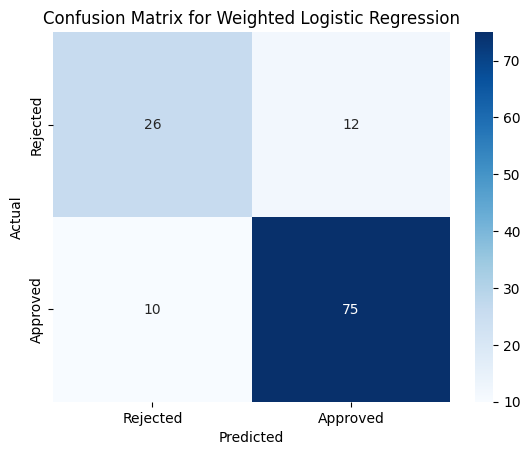

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_weighted)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix for Weighted Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# after evaluating logistic regression, random forest, and weighted logistic regression models, we select the weighted logistic regression model because it gives maximum recall, which is important for this use case (we want to minimize false negatives — i.e., we don't want to reject applicants who would have been approved).
# Save the model and scaler for later use in the API
# we select the weighted logistic regression model because it gives maximum recall, which is important for this use case (we want to minimize false negatives — i.e., we don't want to reject applicants who would have been approved)
import joblib

joblib.dump(model_weighted, '../models/loan_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(list(X_train.columns), '../models/model_columns.pkl')